In [ ]:
# ================================================================
# CELL 0 - INPUT READING & COLUMN RESOLUTION  (generic, v11)
# ================================================================
import os
import math
import pandas as pd
import numpy as np

# --- run configuration (no code editing needed for batch runs) ---
INTERACTIVE = os.environ.get("TEA_INTERACTIVE", "1") != "0"
ASK_EXCEL_FILE = True          # set False to always take the default without asking
EXCEL_FILE = os.environ.get("TEA_EXCEL_FILE", "TEA_Input_Tables.xlsx")


def _xlsx_here():
    return sorted(f for f in os.listdir('.')
                  if f.lower().endswith(('.xlsx', '.xlsm')) and not f.startswith('~$'))


if INTERACTIVE and ASK_EXCEL_FILE:
    _available = _xlsx_here()
    if _available:
        print("Excel files in this folder:")
        for _i, _f in enumerate(_available, 1):
            print(f"  {_i}. {_f}")
    _chosen = None
    while _chosen is None:
        _raw = input(f"\nWhich input file? [{EXCEL_FILE}] (name or number, Enter = default): ").strip()
        if _raw == '':
            _cand = EXCEL_FILE
        elif _raw.isdigit() and 1 <= int(_raw) <= len(_available):
            _cand = _available[int(_raw) - 1]
        else:
            _cand = _raw
        if os.path.isfile(_cand):
            _chosen = _cand
        else:
            print(f"'{_cand}' not found in {os.getcwd()}. Try again.")
    EXCEL_FILE = _chosen
elif not os.path.isfile(EXCEL_FILE):
    raise FileNotFoundError(
        f"Excel input '{EXCEL_FILE}' not found in {os.getcwd()}. "
        "Set the TEA_EXCEL_FILE environment variable or edit EXCEL_FILE."
    )

print(f"Input file: {EXCEL_FILE}")


# ================================================================
# COLUMN / LABEL RESOLVER
# Tolerant to different column names across Excel files.
# ================================================================
def _norm(x):
    return str(x).strip().lower()


# Columns whose name contains one of these is metadata about another column
# ('Price Unit', 'Price Source', ...) and must not win over the data column itself.
_META_WORDS = ('unit', 'source', 'comment', 'note', 'description', 'remark')


def _best_match(norm_items, keywords):
    """norm_items: list of (original, normalised) pairs. Returns best match or None."""
    matches = [orig for orig, low in norm_items if any(k in low for k in keywords)]
    if len(matches) > 1 and not any(w in k for k in keywords for w in _META_WORDS):
        filtered = [m for m in matches
                    if not any(w in _norm(m) for w in _META_WORDS)]
        if filtered:
            matches = filtered
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        exact = [orig for orig in matches
                 if next(low for o, low in norm_items if o == orig) in keywords]
        if len(exact) == 1:
            return exact[0]
    return None


def resolve_column(df, keywords, purpose, sheet_label, required=True):
    """Find which column of df matches `purpose`.
    required=False -> returns None instead of asking (used for optional columns)."""
    norm_items = [(c, _norm(c)) for c in df.columns]
    best = _best_match(norm_items, keywords)
    if best is not None:
        return best
    if not required:
        return None
    if not INTERACTIVE:
        raise KeyError(
            f"Could not identify the '{purpose}' column in sheet '{sheet_label}'. "
            f"Available columns: {list(df.columns)}"
        )
    print(f"\nCould not confidently identify the '{purpose}' column in sheet '{sheet_label}'.")
    print(f"Available columns: {list(df.columns)}")
    while True:
        choice = input(f"Which column is '{purpose}'? ").strip()
        if choice in df.columns:
            return choice
        print("That's not one of the listed column names, try again.")


def find_optional_column(df, aliases):
    """Exact (normalised) match only - safe way to pick up NEW optional columns
    without accidentally grabbing an unrelated column."""
    alias_set = {_norm(a) for a in aliases}
    for c in df.columns:
        if _norm(c) in alias_set:
            return c
    return None


def add_optional_column(df, target_name, aliases, default):
    """Rename an optional column to `target_name`, or create it filled with `default`."""
    col = find_optional_column(df, aliases)
    if col is not None:
        if col != target_name:
            df = df.rename(columns={col: target_name})
    else:
        df[target_name] = default
    return df


# ================================================================
# READ SHEETS
# ================================================================
params   = pd.read_excel(EXCEL_FILE, sheet_name='01_Global_Parameters', skiprows=2)
equip    = pd.read_excel(EXCEL_FILE, sheet_name='02_Equipment_List',    skiprows=2)
opex_df  = pd.read_excel(EXCEL_FILE, sheet_name='03_OPEX_Input',        skiprows=2)
factors  = pd.read_excel(EXCEL_FILE, sheet_name='04_CAPEX_Factors',     skiprows=2)
cepci_df = pd.read_excel(EXCEL_FILE, sheet_name='05_CEPCI_Table',       skiprows=2)

# ---------------- 01_Global_Parameters ----------------
c_param = resolve_column(params, ['parameter'], 'Parameter name', '01_Global_Parameters')
c_value = resolve_column(params, ['value'],     'Value',          '01_Global_Parameters')
params = params.rename(columns={c_param: 'Parameter', c_value: 'Value'})
params['Parameter'] = params['Parameter'].astype(str).str.strip()
params = params[params['Parameter'].str.lower() != 'nan']

# product price: exact name first, keyword search only as fallback
if 'product_price' not in set(params['Parameter']):
    _cands = [p for p in params['Parameter'] if 'price' in _norm(p)]
    _cands = [p for p in _cands if _norm(p) not in ('electricity_price',)]
    if len(_cands) == 1:
        params['Parameter'] = params['Parameter'].replace({_cands[0]: 'product_price'})
    elif len(_cands) > 1 and INTERACTIVE:
        print(f"\nSeveral price-like parameters found: {_cands}")
        while True:
            ch = input("Which one is the PRODUCT price? ").strip()
            if ch in _cands:
                params['Parameter'] = params['Parameter'].replace({ch: 'product_price'})
                break
            print("Not one of the listed names, try again.")
    else:
        raise KeyError("No 'product_price' parameter found in 01_Global_Parameters.")

# ---------------- 02_Equipment_List ----------------
equip_map = {
    'Equipment Name':     resolve_column(equip, ['equipment name', 'name'],        'Equipment Name',       '02_Equipment_List'),
    'Type':               resolve_column(equip, ['type'],                          'Equipment Type',       '02_Equipment_List'),
    'C_ref':              resolve_column(equip, ['c_ref', 'reference cost'],       'Reference Cost',       '02_Equipment_List'),
    'S_ref':              resolve_column(equip, ['s_ref', 'reference size'],       'Reference Size',       '02_Equipment_List'),
    'S_new':              resolve_column(equip, ['s_new', 'new size', 'aspen'],    'New Size',             '02_Equipment_List'),
    'Exponent':           resolve_column(equip, ['exponent'],                      'Scaling Exponent',     '02_Equipment_List'),
    'CEPCI_ref_year':     resolve_column(equip, ['cepci', 'ref_year', 'ref year'], 'CEPCI Reference Year', '02_Equipment_List'),
    'f_install':          resolve_column(equip, ['f_install', 'install'],          'Installation Factor',  '02_Equipment_List'),
    'f_material':         resolve_column(equip, ['f_material', 'material'],        'Material Factor',      '02_Equipment_List'),
    'Quantity':           resolve_column(equip, ['quantity', 'qty'],               'Quantity',             '02_Equipment_List'),
}
equip = equip.rename(columns={v: k for k, v in equip_map.items() if v is not None})

# NEW optional per-equipment columns (exact-name match, default = neutral)
equip = add_optional_column(equip, 'f_pressure',    ['f_pressure', 'f_p', 'pressure factor'],           1.0)
equip = add_optional_column(equip, 'f_temperature', ['f_temperature', 'f_t', 'temperature factor'],     1.0)
equip = add_optional_column(equip, 'f_piping',      ['f_piping', 'f_pip', 'piping factor'],             0.0)
equip = add_optional_column(equip, 'FX_rate',       ['fx_rate', 'fx rate', 'exchange rate'],            np.nan)
equip = add_optional_column(equip, 'Apply_factors', ['apply_factors', 'apply factors'],                 'Y')
equip = add_optional_column(equip, 'Replacement_interval_years',
                            ['replacement_interval_years', 'replacement interval', 'replacement_years'], 0.0)
equip = add_optional_column(equip, 'Replacement_fraction',
                            ['replacement_fraction', 'replacement cost fraction'],                       1.0)
equip = equip.dropna(subset=['Equipment Name'])

for _c, _d in [('f_install', 1.0), ('f_material', 1.0), ('f_pressure', 1.0),
               ('f_temperature', 1.0), ('f_piping', 0.0), ('Quantity', 1.0),
               ('Replacement_interval_years', 0.0), ('Replacement_fraction', 1.0)]:
    equip[_c] = pd.to_numeric(equip[_c], errors='coerce').fillna(_d).astype(float)
equip['FX_rate'] = pd.to_numeric(equip['FX_rate'], errors='coerce')

# ---------------- 03_OPEX_Input ----------------
opex_map = {
    'Item':            resolve_column(opex_df, ['item', 'component', 'name'],   'Item name',       '03_OPEX_Input'),
    'Category':        resolve_column(opex_df, ['category', 'type'],            'Category',        '03_OPEX_Input'),
    'Annual Quantity': resolve_column(opex_df, ['annual quantity', 'quantity'], 'Annual Quantity', '03_OPEX_Input'),
    'Price':           resolve_column(opex_df, ['price', 'cost'],               'Price',           '03_OPEX_Input'),
}
opex_df = opex_df.rename(columns={v: k for k, v in opex_map.items() if v is not None})
opex_df = opex_df.dropna(subset=['Item'])
opex_df['Annual Quantity'] = pd.to_numeric(opex_df['Annual Quantity'], errors='coerce').fillna(0.0)
opex_df['Price'] = pd.to_numeric(opex_df['Price'], errors='coerce').fillna(0.0)


def classify_opex_category(value):
    """Per-row classification - no ambiguous global label matching."""
    s = _norm(value)
    if 'labour' in s or 'labor' in s:
        return 'Labour'
    if any(k in s for k in ('byproduct', 'by-product', 'by product', 'co-product',
                            'coproduct', 'credit', 'revenue', 'sales')):
        return 'Byproduct'
    return 'Variable'


opex_df['Class'] = opex_df['Category'].apply(classify_opex_category)
if not (opex_df['Class'] == 'Labour').any():
    print("WARNING: no OPEX row classified as 'Labour' -> operating labour (OL) will be 0.")
_bp_neg = opex_df[(opex_df['Class'] == 'Byproduct') & (opex_df['Price'] < 0)]
if len(_bp_neg):
    print("WARNING: rows " + ", ".join(_bp_neg['Item'].astype(str)) +
          " are classified as 'Byproduct' AND have a negative price -> the sign is applied "
          "twice and the credit becomes a cost. Use EITHER Category='Byproduct' with a "
          "positive price, OR any other category with a negative price.")

# ---------------- 04_CAPEX_Factors ----------------
factors_map = {
    'Cost Component': resolve_column(factors, ['component', 'item', 'name'], 'Cost Component Name',     '04_CAPEX_Factors'),
    'Factor':         resolve_column(factors, ['factor', '%', 'percent'],    'Factor value',            '04_CAPEX_Factors'),
    'Type':           resolve_column(factors, ['type', 'category'],          'Direct/Indirect/WC type', '04_CAPEX_Factors'),
}
factors = factors.rename(columns={v: k for k, v in factors_map.items() if v is not None})
factors = factors.dropna(subset=['Cost Component'])
factors['Factor'] = pd.to_numeric(factors['Factor'], errors='coerce').fillna(0.0)
# NEW optional column: 'TPEC' (parallel, default) or 'cascade' (NETL-style running subtotal)
factors = add_optional_column(factors, 'Basis', ['basis', 'base'], 'TPEC')
factors['Basis'] = factors['Basis'].fillna('TPEC')


def classify_capex_type(value):
    s = _norm(value)
    if 'working' in s or s in ('wc', 'wci'):
        return 'WC'
    if 'indirect' in s:
        return 'Indirect'
    if 'direct' in s:
        return 'Direct'
    return 'Indirect'   # anything else is treated as an indirect capital adder


factors['TypeClass'] = factors['Type'].apply(classify_capex_type)

# ---------------- 05_CEPCI_Table ----------------
cepci_map = {
    'Year':  resolve_column(cepci_df, ['year'],  'Year',  '05_CEPCI_Table'),
    'CEPCI': resolve_column(cepci_df, ['cepci'], 'CEPCI', '05_CEPCI_Table'),
}
cepci_df = cepci_df.rename(columns={v: k for k, v in cepci_map.items() if v is not None})
cepci_df = cepci_df.dropna(subset=['Year', 'CEPCI'])
cepci_lookup = {int(y): float(c) for y, c in zip(cepci_df['Year'], cepci_df['CEPCI'])}

# ---------------- 06_OPEX_Factors (OPTIONAL) ----------------
OPEX_FACTOR_MODE = 'legacy'      # 'legacy' (Towler skeleton) or 'generic' (data-driven)
opex_factor_dict = {}
opex_factor_rows = []
try:
    _of = pd.read_excel(EXCEL_FILE, sheet_name='06_OPEX_Factors', skiprows=2)
    _fname = resolve_column(_of, ['factor name', 'item', 'name', 'factor'], 'Factor Name', '06_OPEX_Factors')
    _fval  = resolve_column(_of, ['value'], 'Value', '06_OPEX_Factors')
    _of = _of.rename(columns={_fname: 'Factor Name', _fval: 'Value'})
    _of = _of.dropna(subset=['Factor Name'])
    _of['Value'] = pd.to_numeric(_of['Value'], errors='coerce').fillna(0.0)
    _basis_col = find_optional_column(_of, ['basis', 'base'])
    if len(_of) == 0:
        # the sheet exists as part of the standard template but has no rows
        raise ValueError('empty 06_OPEX_Factors')
    if _basis_col is not None:
        OPEX_FACTOR_MODE = 'generic'
        _of = _of.rename(columns={_basis_col: 'Basis'})
        opex_factor_rows = [
            (str(r['Factor Name']).strip(), float(r['Value']), str(r['Basis']).strip())
            for _, r in _of.iterrows()
        ]
        print(f"06_OPEX_Factors found WITH a 'Basis' column -> generic (data-driven) fixed-OPEX mode, "
              f"{len(opex_factor_rows)} item(s).")
    else:
        opex_factor_dict = dict(zip(_of['Factor Name'].astype(str).str.strip(), _of['Value']))
        print(f"06_OPEX_Factors found (no 'Basis' column) -> legacy Towler skeleton with "
              f"{len(opex_factor_dict)} custom factor(s).")
except (ValueError, FileNotFoundError):
    print("No usable 06_OPEX_Factors rows -> legacy Towler & Sinnott default factors.")

if (equip['f_install'] != 1.0).any():
    print("NOTE: f_install is APPLIED in v11 (it was silently ignored in v10). "
          "If your 04_CAPEX_Factors sheet already contains installation adders, "
          "set f_install = 1 to avoid double counting.")

print("\nExcel read successfully, column/label names resolved.")
print(f"  Equipment items : {len(equip)}")
print(f"  OPEX items      : {len(opex_df)}  "
      f"(variable={sum(opex_df['Class']=='Variable')}, "
      f"byproduct={sum(opex_df['Class']=='Byproduct')}, "
      f"labour={sum(opex_df['Class']=='Labour')})")
print(f"  CAPEX factors   : {len(factors)}")
print()
print(equip[['Equipment Name', 'Type', 'S_new', 'Quantity', 'f_install', 'f_material']].to_string(index=False))

Excel files in this folder:
  1. P1c_Gelten_electrolysis_MeOH (1).xlsx
  2. P2b_Khan_CLR_capture (1).xlsx
  3. P3a_Andersson_NH3_standalone_cost (1).xlsx
  4. TEA_Input_Tables.xlsx
  5. TEA_Input_Tables_CO2Removal.xlsx
  6. TEA_Input_Tables_Styrene.xlsx
  7. TEA_Input_Tables_eMethanol.xlsx
  8. Techno-Eco-Tool_final.xlsm
Input file: TEA_Input_Tables.xlsx
No usable 06_OPEX_Factors rows -> legacy Towler & Sinnott default factors.
NOTE: f_install is APPLIED in v11 (it was silently ignored in v10). If your 04_CAPEX_Factors sheet already contains installation adders, set f_install = 1 to avoid double counting.

Excel read successfully, column/label names resolved.
  Equipment items : 25
  OPEX items      : 8  (variable=7, byproduct=0, labour=1)
  CAPEX factors   : 14

Equipment Name           Type     S_new  Quantity  f_install  f_material
  Compressor 1     Compressor 11500.000       1.0        2.5         1.0
  Compressor 2     Compressor 11160.000       1.0        2.5         1.0
  Compr

In [ ]:
# ================================================================
# CELL 1 - GLOBAL PARAMETERS  (all new ones optional)
# ================================================================
param_dict = dict(zip(params['Parameter'].astype(str).str.strip(), params['Value']))


def P(name, default=None, cast=None):
    """Read a parameter with a default; blank/NaN cells fall back to the default."""
    v = param_dict.get(name, default)
    if v is None:
        v = default
    elif isinstance(v, float) and math.isnan(v):
        v = default
    elif isinstance(v, str) and v.strip() == '':
        v = default
    if v is not None and cast is not None:
        v = cast(v)
    return v


# --- required ---
CEPCI_current  = float(P('CEPCI_current'))
discount_rate  = float(P('discount_rate'))
plant_lifetime = int(P('plant_lifetime'))
product_price  = float(P('product_price'))

# --- optional / with sensible defaults ---
USD_to_EUR = float(P('USD_to_EUR', 1.0))
tax_rate   = float(P('tax_rate', 0.0))

capacity_factor = P('capacity_factor', None, float)
operating_hours = P('operating_hours', None, float)
if operating_hours is None:
    if capacity_factor is None:
        raise KeyError("Provide either 'operating_hours' or 'capacity_factor' in 01_Global_Parameters.")
    operating_hours = 8760.0 * capacity_factor
operating_hours = float(operating_hours)

depreciation_years = int(P('depreciation_years', plant_lifetime))
salvage_fraction   = float(P('salvage_fraction', 0.0))
location_factor    = float(P('location_factor', 1.0))
recover_working_capital = str(P('recover_working_capital', 'Y')).strip().upper() not in ('N', 'NO', 'FALSE', '0')
tax_loss_carryforward   = str(P('tax_loss_carryforward', 'Y')).strip().upper() not in ('N', 'NO', 'FALSE', '0')

opex_convention = str(P('opex_convention', 'voc_only')).strip().lower()
if opex_convention not in ('voc_only', 'full'):
    print(f"WARNING: unrecognised opex_convention '{opex_convention}' -> 'voc_only'.")
    opex_convention = 'voc_only'

opex_method = str(P('opex_method', 'factorial')).strip().lower()
if opex_method not in ('factorial', 'turton_lumped'):
    print(f"WARNING: unrecognised opex_method '{opex_method}' -> 'factorial'.")
    opex_method = 'factorial'

capex_factor_basis = str(P('capex_factor_basis', 'corrected')).strip().lower()
if capex_factor_basis not in ('corrected', 'bare'):
    print(f"WARNING: unrecognised capex_factor_basis '{capex_factor_basis}' -> 'corrected'.")
    capex_factor_basis = 'corrected'

acc_basis = str(P('acc_basis', 'FCI')).strip().upper()
if acc_basis not in ('FCI', 'TCI'):
    print(f"WARNING: unrecognised acc_basis '{acc_basis}' -> 'FCI'.")
    acc_basis = 'FCI'

annuity_override = P('annuity_override', None, float)   # published annuity factor, if any
target_IRR       = P('target_IRR', None, float)            # e.g. 0.15 -> required selling price
sensitivity_range = float(P('sensitivity_range', 0.20))    # 0.25 for +/-25% studies
_irr_raw = str(P('irr_targets', '0.10,0.15,0.20')).strip()
irr_targets = [float(x) for x in _irr_raw.split(',') if x.strip() != ''] or [0.10, 0.15, 0.20]

# Turton lumped-OPEX coefficients: OPEX = a*CAPEX_basis + b*OL + c*(utilities+waste+raw)
turton_a     = float(P('turton_a', 0.280))
turton_b     = float(P('turton_b', 2.73))
turton_c     = float(P('turton_c', 1.23))
turton_basis = str(P('turton_basis', 'bare')).strip().lower()

construction_years = int(P('construction_years', 0))
_ramp_raw = str(P('ramp_up_schedule', '1.0')).strip()
ramp_up_schedule = [float(x) for x in _ramp_raw.split(',') if x.strip() != '']
if not ramp_up_schedule:
    ramp_up_schedule = [1.0]


def ramp_fraction(operating_year_index, schedule=None):
    """operating_year_index: 1 = first operating year. Last value repeats afterwards."""
    sch = schedule if schedule is not None else ramp_up_schedule
    idx = operating_year_index - 1
    return sch[idx] if idx < len(sch) else sch[-1]


# --- production rate ---
# ASK_PRODUCTION_RATE = True  -> the notebook asks every run, offering the value stored in
#                               01_Global_Parameters as the default (press Enter to accept).
# ASK_PRODUCTION_RATE = False -> the Excel value is used silently.
# Either way, a batch run (INTERACTIVE = False) never blocks on the prompt.
ASK_PRODUCTION_RATE = True

_unit_col = find_optional_column(params, ['unit', 'units'])
param_units = (dict(zip(params['Parameter'].astype(str).str.strip(), params[_unit_col]))
               if _unit_col is not None else {})
_pr_unit = str(param_units.get('production_rate', '') or '').strip()

production_rate = P('production_rate', None, float)
if production_rate is None and os.environ.get('TEA_PRODUCTION_RATE'):
    production_rate = float(os.environ['TEA_PRODUCTION_RATE'])
_default_pr = production_rate if (production_rate is not None and production_rate > 0) else None

if INTERACTIVE and (ASK_PRODUCTION_RATE or _default_pr is None):
    _hint = f" [{_default_pr:g}{' ' + _pr_unit if _pr_unit else ''}]" if _default_pr else ""
    _prompt = (f"Production rate per operating hour{_hint} "
               f"(must match the denominator of product_price): ")
    production_rate = None
    while production_rate is None:
        raw = input(_prompt).strip()
        if raw == '' and _default_pr is not None:
            production_rate = _default_pr
            break
        try:
            v = float(raw)
            if v > 0:
                production_rate = v
            else:
                print("Please enter a positive number.")
        except ValueError:
            print("Not a valid number, try again.")
elif _default_pr is None:
    raise KeyError("Add 'production_rate' (product unit per hour) to 01_Global_Parameters, "
                   "or set the TEA_PRODUCTION_RATE environment variable.")
else:
    production_rate = _default_pr


def crf(r, n):
    """Capital recovery factor; safe at r = 0 (needed for NETL-style zero-interest studies)."""
    if abs(r) < 1e-12:
        return 1.0 / n
    return r * (1 + r) ** n / ((1 + r) ** n - 1)


def crf_eff(r, n):
    """Uses the user-supplied annuity factor only for the base case (r, n)."""
    if annuity_override is not None and abs(r - discount_rate) < 1e-12 and n == plant_lifetime:
        return annuity_override
    return crf(r, n)


print("Global parameters loaded.")
print(f"  CEPCI current       : {CEPCI_current}")
print(f"  Discount rate       : {discount_rate*100:.2f} %   (CRF = {crf_eff(discount_rate, plant_lifetime):.5f})")
print(f"  Plant lifetime      : {plant_lifetime} y   | depreciation over {depreciation_years} y")
print(f"  Operating hours     : {operating_hours:,.0f} h/y")
print(f"  Production rate     : {production_rate:,.3f} unit/h  -> {production_rate*operating_hours:,.0f} unit/y")
print(f"  Product price       : {product_price:,.2f} per unit")
print(f"  Tax rate            : {tax_rate*100:.1f} %")
print(f"  OPEX method         : {opex_method}   | convention: {opex_convention}")
print(f"  CAPEX factor basis  : {capex_factor_basis}   | ACC basis: {acc_basis}")
print(f"  Construction years  : {construction_years}   | ramp-up: {ramp_up_schedule}")
if annuity_override is not None:
    print(f"  Annuity override    : {annuity_override}")
if target_IRR is not None:
    print(f"  Target IRR          : {target_IRR*100:.1f} %")

Not a valid number, try again.
Not a valid number, try again.
Global parameters loaded.
  CEPCI current       : 596.2
  Discount rate       : 10.00 %   (CRF = 0.11746)
  Plant lifetime      : 20 y   | depreciation over 20 y
  Operating hours     : 8,000 h/y
  Production rate     : 2.400 unit/h  -> 19,200 unit/y
  Product price       : 920.00 per unit
  Tax rate            : 0.0 %
  OPEX method         : factorial   | convention: voc_only
  CAPEX factor basis  : corrected   | ACC basis: FCI
  Construction years  : 0   | ramp-up: [1.0]


In [ ]:
# ================================================================
# CELL 1b - INPUT VALIDATION
# ================================================================
_issues = []


def _add(level, topic, msg, item=None):
    _issues.append((level, topic, msg, item))


# ---------- 1. equipment sheet ----------
_dup = equip['Equipment Name'][equip['Equipment Name'].duplicated()].tolist()
if _dup:
    _add('WARN', 'duplicate names',
         f"repeated equipment names {sorted(set(_dup))} - use Quantity instead, "
         "duplicates confuse the sensitivity table.")

for _, _r in equip.iterrows():
    _nm = _r['Equipment Name']
    if not (float(_r['C_ref']) > 0):
        _add('ERROR', 'equipment cost', f"'{_nm}': C_ref must be > 0.")
    if not (float(_r['S_ref']) > 0):
        _add('ERROR', 'equipment size', f"'{_nm}': S_ref must be > 0.")
        continue
    if int(_r['CEPCI_ref_year']) not in cepci_lookup:
        _add('ERROR', 'CEPCI', f"'{_nm}': year {int(_r['CEPCI_ref_year'])} is not in 05_CEPCI_Table.")
    _ratio = float(_r['S_new']) / float(_r['S_ref'])
    _exp = float(_r['Exponent'])
    # S_ref = 1 with exponent = 1 is the "unit cost" style (e.g. 270 EUR/kW x 20,000 kW):
    # perfectly linear by construction, so the validity-range check does not apply.
    _unit_cost_entry = (abs(float(_r['S_ref']) - 1.0) < 1e-12 and abs(_exp - 1.0) < 1e-12)
    if _unit_cost_entry:
        pass
    elif _ratio > 5 or _ratio < 0.2:
        _mult = _ratio ** _exp
        _add('WARN', 'scaling range',
             f"'{_nm}': S_new/S_ref = {_ratio:,.1f} (cost multiplier {_mult:,.1f}). Power-law "
             "correlations are usually valid within about 0.2-5x of the reference size; "
             "consider parallel units or a closer reference.", _nm)
    if _unit_cost_entry:
        pass
    elif _exp > 1.0:
        _add('WARN', 'scaling exponent',
             f"'{_nm}': exponent {_exp} > 1 means diseconomy of scale - unusual, please confirm.",
             _nm)
    elif _exp < 0.3:
        _add('WARN', 'scaling exponent',
             f"'{_nm}': exponent {_exp} < 0.3 is unusually flat.", _nm)

# ---------- 2. installation double counting ----------
_inst_kw = ('install', 'erection', 'lang', 'long factor', 'montage', 'bare module')
_inst_rows = [str(r['Cost Component']) for _, r in factors.iterrows()
              if any(k in _norm(r['Cost Component']) for k in _inst_kw)]
if (equip['f_install'] != 1.0).any() and _inst_rows:
    _w = float((equip['C_ref'] * equip['Quantity'] * equip['f_install']).sum() /
               max((equip['C_ref'] * equip['Quantity']).sum(), 1e-9))
    _f04 = float(sum(r['Factor'] for _, r in factors.iterrows()
                     if any(k in _norm(r['Cost Component']) for k in _inst_kw)))
    _add('ERROR', 'installation counted twice',
         f"f_install is non-unity (weighted x{_w:.2f}) AND 04_CAPEX_Factors contains "
         f"{_inst_rows} (+{_f04:.2f} x TPEC). These are alternatives, not additive. "
         "Set f_install = 1, or delete those factor rows.")

# ---------- 3. currency / index ----------
if 1.02 < USD_to_EUR < 1.6:
    _add('WARN', 'exchange rate',
         f"USD_to_EUR = {USD_to_EUR}: costs are MULTIPLIED by it, so this says one unit of the "
         f"equipment currency is worth {USD_to_EUR} of the report currency. If the rate you meant "
         f"was '1 EUR = {USD_to_EUR} USD', the correct multiplier is {1/USD_to_EUR:.4f}.")
_cep_ratio = [CEPCI_current / cepci_lookup[int(y)] for y in equip['CEPCI_ref_year']
              if int(y) in cepci_lookup]
if _cep_ratio and (max(_cep_ratio) > 3 or min(_cep_ratio) < 0.5):
    _add('WARN', 'CEPCI escalation',
         f"cost index ratio spans {min(_cep_ratio):.2f}-{max(_cep_ratio):.2f}; check that "
         "CEPCI_current and the reference years are the ones you intend.")

# ---------- 4. OPEX sheet ----------
_dup_o = opex_df['Item'][opex_df['Item'].duplicated()].tolist()
if _dup_o:
    _add('WARN', 'duplicate names', f"repeated OPEX item names {sorted(set(_dup_o))}.")
for _, _r in opex_df.iterrows():
    if float(_r['Annual Quantity']) * float(_r['Price']) == 0:
        _add('WARN', 'zero cost',
             f"OPEX item '{_r['Item']}' evaluates to 0 per year.", _r['Item'])
if not (opex_df['Class'] == 'Labour').any():
    _add('WARN', 'labour', "no row with a Labour category - operating labour is 0.")

# ---------- 5. financial parameters ----------
if operating_hours > 8760:
    _add('ERROR', 'operating hours', f"{operating_hours:,.0f} h/y exceeds 8,760 h in a year.")
else:
    _add('INFO', 'capacity factor', f"{operating_hours/8760*100:.1f} % ({operating_hours:,.0f} h/y).")
if depreciation_years > plant_lifetime:
    _add('WARN', 'depreciation', "depreciation_years > plant_lifetime; the tail is never claimed.")
if abs(discount_rate) < 1e-12:
    _add('INFO', 'discount rate', "0 % - CRF becomes 1/n. NPV/IRR/payback are meaningless; "
                                  "compare LCOP only.")
if tax_rate > 0 and opex_convention == 'voc_only':
    _add('WARN', 'tax vs OPEX convention',
         "tax is charged on revenue minus VARIABLE cost only, so taxable income (and tax) is "
         "overstated. Use opex_convention = full when a tax rate is set.")
if any(f <= 0 or f > 1.0 for f in ramp_up_schedule):
    _add('WARN', 'ramp-up', f"ramp_up_schedule {ramp_up_schedule} has values outside (0, 1].")
_repl = equip[equip['Replacement_interval_years'] > 0]
for _, _r in _repl.iterrows():
    if _r['Replacement_interval_years'] >= plant_lifetime:
        _add('INFO', 'replacement',
             f"'{_r['Equipment Name']}': interval >= plant lifetime, so no replacement occurs.")

# ---------- 6. CAPEX / OPEX factor sheets ----------
if factors['Factor'].sum() <= 0:
    _add('WARN', 'CAPEX factors', "all factors in 04_CAPEX_Factors are zero - FCI = TPEC.")
if OPEX_FACTOR_MODE == 'generic':
    _allowed = {'ol', 'labour', 'labor', 'fci', 'tci', 'wci', 'tpec', 'tpec_bare', 'bare',
                'voc', 'directopex', 'direct_opex', 'acc', 'totalopex', 'total_opex', 'opex',
                'com', 'total opex', 'npc', 'npc_total', '', 'nan', 'absolute', 'fixed', 'none'}
    _stages = {_norm(c) for c in factors['Cost Component']}
    _seen, _implicit_sum = set(), 0.0
    for _n, _v, _b in opex_factor_rows:
        _bn = _norm(_b)
        if _bn in ('totalopex', 'total_opex', 'opex', 'com', 'total opex', 'npc', 'npc_total'):
            _implicit_sum += _v
        elif _bn not in _allowed and _bn not in _stages and _bn not in _seen:
            _add('ERROR', '06_OPEX_Factors',
                 f"'{_n}': Basis '{_b}' is not a known base, a previous factor name, or a row "
                 "of 04_CAPEX_Factors.")
        _seen.add(_norm(_n))
    if _implicit_sum >= 1.0:
        _add('ERROR', '06_OPEX_Factors',
             f"implicit factors (basis TotalOPEX/NPC) sum to {_implicit_sum:.2f} >= 1 - the "
             "fixed-point iteration cannot converge.")

# ---------- report ----------
_order = {'ERROR': 0, 'WARN': 1, 'INFO': 2}
_issues.sort(key=lambda x: _order[x[0]])
print("=" * 78)
print("INPUT VALIDATION")
print("=" * 78)
if not any(i[0] == 'ERROR' for i in _issues):
    print("No blocking problems found.")

_printed = set()
for _lvl, _topic, _msg, _item in _issues:
    if (_lvl, _topic) in _printed:
        continue
    _same = [i for i in _issues if (i[0], i[1]) == (_lvl, _topic)]
    if len(_same) > 3 and all(i[3] for i in _same):
        print(f"[{_lvl:5}] {_topic} - {len(_same)} items, e.g. {_same[0][2]}")
        print(f"         also: {', '.join(str(i[3]) for i in _same[1:])}")
        _printed.add((_lvl, _topic))
    else:
        print(f"[{_lvl:5}] {_topic}: {_msg}")
        if len(_same) == 1:
            _printed.add((_lvl, _topic))
_printed = set()
print("=" * 78)
if any(i[0] == 'ERROR' for i in _issues):
    print("!! At least one ERROR above. The cells below will still run, but the numbers "
          "are not trustworthy until it is resolved.")


def sanity_report(base):
    """Result-level checks; called at the end of the KPI cell."""
    out = []
    cap, op = base['capex'], base['opex']
    if cap['TPEC'] > 0:
        _r = cap['FCI'] / cap['TPEC']
        if _r < 1.0 or _r > 12.0:
            out.append(f"[WARN ] FCI / TPEC = {_r:.2f}. Typical factorial estimates land between "
                       "about 2 and 7; check 04_CAPEX_Factors.")
    if base['LCOP'] > 0 and product_price > 0:
        _r = base['LCOP'] / product_price
        if _r > 10 or _r < 0.1:
            out.append(f"[WARN ] LCOP is {_r:.1f}x the product price. That usually means "
                       "production_rate and product_price use different units "
                       f"(LCOP = {base['LCOP']:,.2f}, price = {product_price:,.2f}).")
    if opex_convention == 'voc_only' and op['FOC'] > 0:
        out.append(f"[INFO ] opex_convention = voc_only: {op['FOC']/1e6:,.2f} M/y of fixed OPEX "
                   "is EXCLUDED from the cash flow (it is still inside LCOP). Set "
                   "opex_convention = full if the study charges fixed costs against revenue.")
    if op['OPEX_total'] != 0 and len(op['df_direct']):
        _top = op['df_direct'].reindex(
            op['df_direct']['Annual Cost (M)'].abs().sort_values(ascending=False).index).iloc[0]
        out.append(f"[INFO ] largest variable cost: {_top['Item']} = "
                   f"{_top['Annual Cost (M)']:,.2f} M/y "
                   f"({abs(_top['Annual Cost (M)'])*1e6/abs(op['OPEX_total'])*100:.0f} % of total OPEX).")
    if base['IRR'] != base['IRR']:
        out.append("[INFO ] IRR is undefined: the discounted cash flow never crosses zero.")
    print("\n".join(out) if out else "[INFO ] result-level checks passed.")

INPUT VALIDATION
[ERROR] installation counted twice: f_install is non-unity (weighted x2.67) AND 04_CAPEX_Factors contains ['Equipment Installation'] (+0.47 x TPEC). These are alternatives, not additive. Set f_install = 1, or delete those factor rows.
[WARN ] scaling range - 10 items, e.g. 'Compressor 5': S_new/S_ref = 0.2 (cost multiplier 0.3). Power-law correlations are usually valid within about 0.2-5x of the reference size; consider parallel units or a closer reference.
         also: HX-1, HX-2, HX-4, HX-5, HX-7, Reactor, Condenser, Reboiler, Fired Heater
[WARN ] scaling exponent - 9 items, e.g. 'HX-1': exponent 1.2 > 1 means diseconomy of scale - unusual, please confirm.
         also: HX-2, HX-3, HX-4, HX-5, HX-6, HX-7, HX-8, Packed Column
[INFO ] capacity factor: 91.3 % (8,000 h/y).
!! At least one ERROR above. The cells below will still run, but the numbers are not trustworthy until it is resolved.


In [ ]:
# ================================================================
# CELL 2 - CAPEX ENGINE
# ================================================================
def compute_capex(capex_mult=1.0, verbose=False):
    """Returns a dict with TPEC_bare, TPEC, FCI, WCI, TCI, per-item table,
    the cascade stage subtotals and the replacement-cost events."""
    rows = []
    replacements = []
    for _, row in equip.iterrows():
        year_ref = int(row['CEPCI_ref_year'])
        if year_ref not in cepci_lookup:
            raise KeyError(f"CEPCI year {year_ref} (item '{row['Equipment Name']}') "
                           f"is missing from sheet 05_CEPCI_Table.")
        cepci_ref = cepci_lookup[year_ref]

        s_ratio = float(row['S_new']) / float(row['S_ref'])
        C_scaled = float(row['C_ref']) * s_ratio ** float(row['Exponent'])
        C_cepci = C_scaled * (CEPCI_current / cepci_ref)

        fx = row['FX_rate'] if pd.notna(row['FX_rate']) else USD_to_EUR
        C_bare = C_cepci * float(fx) * float(row['Quantity']) * capex_mult

        apply_f = str(row['Apply_factors']).strip().upper() not in ('N', 'NO', 'FALSE', '0')
        if apply_f:
            mult = (float(row['f_material']) * float(row['f_pressure']) *
                    float(row['f_temperature']) * (1.0 + float(row['f_piping'])) *
                    float(row['f_install']))
        else:
            mult = 1.0
        C_corr = C_bare * mult

        rows.append({
            'Equipment': row['Equipment Name'],
            'Bare Cost (M)': C_bare / 1e6,
            'Factor': mult,
            'Corrected Cost (M)': C_corr / 1e6,
            'In factor basis': 'Y' if apply_f else 'N',
        })

        interval = float(row['Replacement_interval_years'])
        if interval > 0:
            replacements.append({
                'Equipment': row['Equipment Name'],
                'interval': interval,
                'cost': C_corr * float(row['Replacement_fraction']),
            })

    df_capex = pd.DataFrame(rows)
    TPEC_bare = float(sum(r['Bare Cost (M)'] for r in rows)) * 1e6
    TPEC      = float(sum(r['Corrected Cost (M)'] for r in rows)) * 1e6

    # Items flagged Apply_factors = N are excluded from the basis the global
    # 04_CAPEX_Factors adders act on (e.g. a skid-mounted package unit that
    # carries no erection / piping / civil works).
    basis_bare = float(sum(r['Bare Cost (M)'] for r in rows
                           if r['In factor basis'] == 'Y')) * 1e6
    basis_corr = float(sum(r['Corrected Cost (M)'] for r in rows
                           if r['In factor basis'] == 'Y')) * 1e6
    basis = basis_bare if capex_factor_basis == 'bare' else basis_corr

    running = basis
    direct = indirect = wc = 0.0
    stages = {}
    stage_rows = []
    for _, f in factors.iterrows():
        cascade = _norm(f['Basis']).startswith(('casc', 'run', 'sub'))
        base = running if cascade else basis
        amount = float(f['Factor']) * base
        if f['TypeClass'] == 'WC':
            wc += amount
        else:
            if f['TypeClass'] == 'Direct':
                direct += amount
            else:
                indirect += amount
            running += amount
        stages[str(f['Cost Component']).strip()] = running
        stage_rows.append({'Cost Component': f['Cost Component'], 'Type': f['TypeClass'],
                           'Basis': 'cascade' if cascade else 'TPEC',
                           'Amount (M)': amount / 1e6, 'Subtotal (M)': running / 1e6})

    FCI = (TPEC + direct + indirect) * location_factor
    WCI = wc * location_factor
    TCI = FCI + WCI

    out = {
        'df_items': df_capex, 'df_stages': pd.DataFrame(stage_rows),
        'TPEC_bare': TPEC_bare, 'TPEC': TPEC, 'factor_basis': basis,
        'direct': direct * location_factor, 'indirect': indirect * location_factor,
        'FCI': FCI, 'WCI': WCI, 'TCI': TCI,
        'stages': {k: v * location_factor for k, v in stages.items()},
        'replacements': replacements,
    }

    if verbose:
        print("=" * 62)
        print("CAPEX SUMMARY")
        print("=" * 62)
        print(df_capex.round(3).to_string(index=False))
        print("-" * 62)
        print(f"TPEC (bare, before item factors): {TPEC_bare/1e6:>10.3f} M")
        print(f"TPEC (after item factors)       : {TPEC/1e6:>10.3f} M")
        if abs(basis - (TPEC_bare if capex_factor_basis == 'bare' else TPEC)) > 1:
            print(f"  basis for 04_CAPEX_Factors    : {basis/1e6:>10.3f} M "
                  f"(items with Apply_factors=N excluded)")
        print(f"  Direct capital adders         : {out['direct']/1e6:>10.3f} M")
        print(f"  Indirect capital adders       : {out['indirect']/1e6:>10.3f} M")
        print(f"FCI                             : {FCI/1e6:>10.3f} M")
        print(f"WCI                             : {WCI/1e6:>10.3f} M")
        print(f"TCI  (location factor {location_factor})       : {TCI/1e6:>10.3f} M")
        if TPEC_bare > 0:
            print(f"Installed/bare ratio (FCI/TPEC_bare): {FCI/TPEC_bare:.3f}")
        if replacements:
            print("Replacement events:", ", ".join(
                f"{r['Equipment']} every {r['interval']:.0f} y ({r['cost']/1e6:.2f} M)" for r in replacements))
        print("=" * 62)
    return out


CAPEX = compute_capex(verbose=True)
FCI, WCI, TCI = CAPEX['FCI'], CAPEX['WCI'], CAPEX['TCI']
TPEC_EUR = CAPEX['TPEC']

CAPEX SUMMARY
    Equipment  Bare Cost (M)  Factor  Corrected Cost (M) In factor basis
 Compressor 1          7.530     2.5              18.826               Y
 Compressor 2          7.376     2.5              18.440               Y
 Compressor 3          7.471     2.5              18.679               Y
 Compressor 4          8.011     2.5              20.029               Y
 Compressor 5          0.947     2.5               2.368               Y
         Pump          0.004     4.0               0.016               Y
 Flash drum 1          0.051     4.0               0.203               Y
 Flash drum 2          0.029     4.0               0.116               Y
 Flash drum 3          0.060     4.0               0.239               Y
 Flash drum 4          0.049     4.0               0.196               Y
         HX-1          0.748     3.5               2.616               Y
         HX-2          0.423     3.5               1.481               Y
         HX-3          0.108     3.5 

In [ ]:
# ================================================================
# CELL 3 - OPEX ENGINE
# ================================================================
def compute_opex(cap, OL_mult=1.0, item_price_mult=None, r=None, verbose=False):
    item_price_mult = item_price_mult or {}
    r = discount_rate if r is None else r

    # ---------- variable (direct) OPEX ----------
    voc_rows = []
    VOC = 0.0
    OL = 0.0
    for _, row in opex_df.iterrows():
        price = float(row['Price']) * float(item_price_mult.get(row['Item'], 1.0))
        amount = float(row['Annual Quantity']) * price
        if row['Class'] == 'Labour':
            OL += amount
            continue
        sign = -1.0 if row['Class'] == 'Byproduct' else 1.0
        amount *= sign
        VOC += amount
        voc_rows.append({'Item': row['Item'], 'Category': row['Category'],
                         'Class': row['Class'], 'Annual Cost (M)': amount / 1e6})
    OL *= float(OL_mult)
    df_direct = pd.DataFrame(voc_rows)

    ACC = crf_eff(r, plant_lifetime) * (cap['TCI'] if acc_basis == 'TCI' else cap['FCI'])

    # ---------- fixed (indirect) OPEX ----------
    if opex_method == 'turton_lumped':
        base_map = {'bare': cap['TPEC_bare'], 'tpec': cap['TPEC'], 'fci': cap['FCI'], 'tci': cap['TCI']}
        cbase = base_map.get(turton_basis, cap['TPEC_bare'])
        OPEX_total = turton_a * cbase + turton_b * OL + turton_c * VOC
        FOC_total = OPEX_total - VOC
        df_fixed = pd.DataFrame([
            {'Item': f'{turton_a}*CAPEX ({turton_basis})', 'Value (M)': turton_a * cbase / 1e6},
            {'Item': f'{turton_b}*Operating labour',       'Value (M)': turton_b * OL / 1e6},
            {'Item': f'({turton_c}-1)*Direct OPEX',        'Value (M)': (turton_c - 1.0) * VOC / 1e6},
        ])

    elif OPEX_FACTOR_MODE == 'generic':
        named = {'ol': OL, 'labour': OL, 'labor': OL,
                 'fci': cap['FCI'], 'tci': cap['TCI'], 'wci': cap['WCI'],
                 'tpec': cap['TPEC'], 'tpec_bare': cap['TPEC_bare'], 'bare': cap['TPEC_bare'],
                 'voc': VOC, 'directopex': VOC, 'direct_opex': VOC, 'acc': ACC}
        stage_lookup = {_norm(k): v for k, v in cap['stages'].items()}

        computed, explicit_rows, implicit_rows = {}, [], []
        for name, value, basis in opex_factor_rows:
            b = _norm(basis)
            if b in ('totalopex', 'total_opex', 'opex', 'com', 'total opex'):
                implicit_rows.append((name, value, 'opex'))
                continue
            if b in ('npc', 'npc_total'):
                implicit_rows.append((name, value, 'npc'))
                continue
            if b in named:
                base = named[b]
            elif b in {_norm(k) for k in computed}:
                base = next(v for k, v in computed.items() if _norm(k) == b)
            elif b in stage_lookup:
                base = stage_lookup[b]
            elif b in ('', 'nan', 'absolute', 'fixed', 'none'):
                base = 1.0     # absolute amount entered directly
            else:
                raise KeyError(
                    f"Unknown Basis '{basis}' for OPEX factor '{name}'. Allowed: "
                    f"{sorted(named)}, a previous factor name, a 04_CAPEX_Factors component name, "
                    f"'TotalOPEX', 'NPC' or 'absolute'.")
            computed[name] = value * base
            explicit_rows.append(name)

        FOC_explicit = sum(computed.values())
        FOC_total = FOC_explicit
        for _ in range(200):
            OPEX_total = VOC + FOC_total
            NPC_it = OPEX_total + ACC
            imp = {n: f * (OPEX_total if k == 'opex' else NPC_it) for n, f, k in implicit_rows}
            new_FOC = FOC_explicit + sum(imp.values())
            if abs(new_FOC - FOC_total) <= 1e-9 * max(1.0, abs(FOC_total)):
                FOC_total = new_FOC
                break
            FOC_total = new_FOC
        if implicit_rows:
            computed.update(imp)
        OPEX_total = VOC + FOC_total
        df_fixed = pd.DataFrame([{'Item': k, 'Value (M)': v / 1e6} for k, v in computed.items()])

    else:   # ---------- legacy Towler & Sinnott skeleton (v10 behaviour) ----------
        OS_factor           = float(opex_factor_dict.get('OS_factor', 0.15))
        maintenance_factor  = float(opex_factor_dict.get('maintenance_factor', 0.02))   # of FCI
        supplies_factor     = float(opex_factor_dict.get('supplies_factor', 0.15))
        lab_charges_factor  = float(opex_factor_dict.get('lab_charges_factor', 0.20))
        insurance_factor    = float(opex_factor_dict.get('insurance_factor', 0.02))
        overhead_factor     = float(opex_factor_dict.get('overhead_factor', 0.60))
        admin_factor        = float(opex_factor_dict.get('admin_factor', 0.25))
        distribution_factor = float(opex_factor_dict.get('distribution_factor', 0.06))
        rd_factor           = float(opex_factor_dict.get('rd_factor', 0.04))

        OS = OS_factor * OL
        maintenance = maintenance_factor * cap['FCI']
        ML = MM = maintenance / 2.0
        supplies = supplies_factor * (ML + MM)
        lab_charges = lab_charges_factor * OL
        insurance = insurance_factor * cap['FCI']
        overhead = overhead_factor * (OL + OS + ML)
        admin = admin_factor * overhead
        FOC_base = OL + OS + ML + MM + supplies + lab_charges + insurance + overhead + admin

        NPC_it = VOC + FOC_base + ACC
        distribution = RD = 0.0
        for _ in range(200):
            distribution = distribution_factor * NPC_it
            RD = rd_factor * NPC_it
            FOC_total = FOC_base + distribution + RD
            OPEX_total = VOC + FOC_total
            new_NPC = OPEX_total + ACC
            if abs(new_NPC - NPC_it) <= 1e-9 * max(1.0, abs(NPC_it)):
                NPC_it = new_NPC
                break
            NPC_it = new_NPC
        FOC_total = FOC_base + distribution + RD
        OPEX_total = VOC + FOC_total
        df_fixed = pd.DataFrame([
            ('Operating Labour', OL), ('Operating Supervision', OS),
            ('Maintenance Labour', ML), ('Maintenance Material', MM),
            ('Operating Supplies', supplies), ('Laboratory Charges', lab_charges),
            ('Insurance and Taxes', insurance), ('Plant Overhead', overhead),
            ('Administrative Costs', admin), ('Distribution & Marketing', distribution),
            ('Research & Development', RD),
        ], columns=['Item', 'Value'])
        df_fixed['Value (M)'] = df_fixed['Value'] / 1e6
        df_fixed = df_fixed[['Item', 'Value (M)']]

    out = {'VOC': VOC, 'FOC': FOC_total, 'OPEX_total': OPEX_total, 'OL': OL, 'ACC': ACC,
           'df_direct': df_direct, 'df_fixed': df_fixed}

    if verbose:
        print("=" * 62)
        print("VARIABLE (DIRECT) OPEX   [Byproduct rows enter with a negative sign]")
        print("=" * 62)
        if len(df_direct):
            print(df_direct.round(3).to_string(index=False))
            print("-" * 62)
            print(df_direct.groupby('Category')['Annual Cost (M)'].sum().round(3).to_string())
        print("-" * 62)
        print(f"Total variable OPEX: {VOC/1e6:.3f} M/y")
        print()
        print("=" * 62)
        mode = ('Turton lumped equation' if opex_method == 'turton_lumped'
                else 'data-driven 06_OPEX_Factors' if OPEX_FACTOR_MODE == 'generic'
                else 'legacy Towler & Sinnott skeleton')
        print(f"FIXED (INDIRECT) OPEX   [{mode}]")
        print("=" * 62)
        print(df_fixed.round(3).to_string(index=False))
        print("-" * 62)
        print(f"Total fixed OPEX : {FOC_total/1e6:.3f} M/y")
        print(f"TOTAL OPEX       : {OPEX_total/1e6:.3f} M/y")
        print(f"(Operating labour OL = {OL/1e6:.3f} M/y ; ACC = {ACC/1e6:.3f} M/y on {acc_basis})")
        print("=" * 62)
    return out


OPEX = compute_opex(CAPEX, verbose=True)
OL = OPEX['OL']
Direct_OPEX = OPEX['VOC'] / 1e6
OPEX_total = OPEX['OPEX_total']

VARIABLE (DIRECT) OPEX   [Byproduct rows enter with a negative sign]
         Item     Category    Class  Annual Cost (M)
  Hydrogen H2 Raw Material Variable          770.633
          CO2 Raw Material Variable           74.956
     Catalyst Raw Material Variable           16.942
  Electricity      Utility Variable           12.663
  Clean water      Utility Variable            0.023
Cooling water      Utility Variable            0.378
 TOC disposal      Utility Variable            0.120
--------------------------------------------------------------
Category
Raw Material    862.530
Utility          13.184
--------------------------------------------------------------
Total variable OPEX: 875.714 M/y

FIXED (INDIRECT) OPEX   [legacy Towler & Sinnott skeleton]
                    Item  Value (M)
        Operating Labour      0.970
   Operating Supervision      0.146
      Maintenance Labour     10.216
    Maintenance Material     10.216
      Operating Supplies      3.065
      Laborator

In [ ]:
# ================================================================
# CELL 4 - CASH FLOW BUILDER
# ================================================================
def build_cashflow(cap, op, prod_rate=None, hours=None, price=None,
                   schedule=None, verbose=False):
    prod_rate = production_rate if prod_rate is None else prod_rate
    hours = operating_hours if hours is None else hours
    price = product_price if price is None else price
    schedule = ramp_up_schedule if schedule is None else schedule

    annual_production_full = prod_rate * hours
    revenue_full = annual_production_full * price
    VOC_full = op['VOC']
    FOC = op['FOC']

    dep_base = cap['FCI'] * (1.0 - salvage_fraction)
    dep_annual = dep_base / depreciation_years

    # replacement events -> {operating_year_index: cost}
    repl = {}
    for rep in cap['replacements']:
        k = 1
        while rep['interval'] * k < plant_lifetime:
            y = int(round(rep['interval'] * k))
            repl[y] = repl.get(y, 0.0) + rep['cost']
            k += 1

    rows = []
    t = 0
    if construction_years > 0:
        fci_per_year = cap['FCI'] / construction_years
        for cy in range(construction_years):
            capex_out = fci_per_year + (cap['WCI'] if cy == construction_years - 1 else 0.0)
            rows.append({'Year (t)': t, 'Phase': 'Construction', 'Ramp %': 0,
                         'Production': 0.0, 'Revenue': 0.0, 'VOC': 0.0, 'FOC': 0.0,
                         'OPEX': 0.0, 'Depreciation': 0.0, 'Taxable': 0.0, 'Tax': 0.0,
                         'CAPEX out': capex_out, 'Cash Flow': -capex_out})
            t += 1
    else:
        rows.append({'Year (t)': 0, 'Phase': 'CAPEX', 'Ramp %': 0,
                     'Production': 0.0, 'Revenue': 0.0, 'VOC': 0.0, 'FOC': 0.0,
                     'OPEX': 0.0, 'Depreciation': 0.0, 'Taxable': 0.0, 'Tax': 0.0,
                     'CAPEX out': cap['FCI'] + cap['WCI'],
                     'Cash Flow': -(cap['FCI'] + cap['WCI'])})
        t = 1

    loss_pool = 0.0
    for oy in range(1, plant_lifetime + 1):
        frac = ramp_fraction(oy, schedule)
        prod = annual_production_full * frac
        rev = revenue_full * frac
        voc = VOC_full * frac                 # variable costs scale with output
        foc = FOC                             # fixed costs do NOT scale with output
        opex_y = voc + foc if opex_convention == 'full' else voc
        dep = dep_annual if oy <= depreciation_years else 0.0

        taxable = rev - opex_y - dep + loss_pool
        if taxable < 0:
            tax = 0.0
            loss_pool = taxable if tax_loss_carryforward else 0.0
        else:
            tax = taxable * tax_rate
            loss_pool = 0.0

        capex_out = repl.get(oy, 0.0)
        terminal = 0.0
        if oy == plant_lifetime:
            if recover_working_capital:
                terminal += cap['WCI']
            terminal += cap['FCI'] * salvage_fraction

        cf = rev - opex_y - tax - capex_out + terminal
        rows.append({'Year (t)': t, 'Phase': 'Operation', 'Ramp %': round(frac * 100),
                     'Production': prod, 'Revenue': rev, 'VOC': voc, 'FOC': foc,
                     'OPEX': opex_y, 'Depreciation': dep,
                     'Taxable': rev - opex_y - dep, 'Tax': tax,
                     'CAPEX out': capex_out - terminal, 'Cash Flow': cf})
        t += 1

    df = pd.DataFrame(rows)
    if verbose:
        show = df.copy()
        for c in ['Revenue', 'VOC', 'FOC', 'OPEX', 'Depreciation', 'Taxable', 'Tax',
                  'CAPEX out', 'Cash Flow']:
            show[c] = (show[c] / 1e6).round(2)
        show['Production'] = (show['Production'] / 1e3).round(1)
        show = show.rename(columns={'Production': 'Prod (k unit)'})
        show['Disc. CF (M)'] = [round(cf / (1 + discount_rate) ** t / 1e6, 2)
                                for cf, t in zip(df['Cash Flow'], df['Year (t)'])]
        show['Cum. DCF (M)'] = show['Disc. CF (M)'].cumsum().round(2)
        print(f"OPEX convention in cash flow: {opex_convention} | tax rate {tax_rate*100:.1f}%")
        print(show.to_string(index=False))
    return df


df_cashflow = build_cashflow(CAPEX, OPEX, verbose=True)

OPEX convention in cash flow: voc_only | tax rate 0.0%
 Year (t)     Phase  Ramp %  Prod (k unit)  Revenue    VOC    FOC   OPEX  Depreciation  Taxable  Tax  CAPEX out  Cash Flow  Disc. CF (M)  Cum. DCF (M)
        0     CAPEX       0            0.0     0.00   0.00   0.00   0.00          0.00     0.00  0.0    1135.08   -1135.08      -1135.08      -1135.08
        1 Operation     100           19.2    17.66 875.71 170.34 875.71         51.08  -909.13  0.0       0.00    -858.05       -780.05      -1915.13
        2 Operation     100           19.2    17.66 875.71 170.34 875.71         51.08  -909.13  0.0       0.00    -858.05       -709.13      -2624.26
        3 Operation     100           19.2    17.66 875.71 170.34 875.71         51.08  -909.13  0.0       0.00    -858.05       -644.67      -3268.93
        4 Operation     100           19.2    17.66 875.71 170.34 875.71         51.08  -909.13  0.0       0.00    -858.05       -586.06      -3854.99
        5 Operation     100           1

In [ ]:
# ================================================================
# CELL 5 - KPIs, IRR, LCOP, REQUIRED SELLING PRICE
# ================================================================
from scipy.optimize import brentq


def npv_of(df, r):
    return float(sum(cf / (1 + r) ** t for cf, t in zip(df['Cash Flow'], df['Year (t)'])))


def irr_of(df):
    f = lambda r: npv_of(df, r)
    lo = -0.95
    try:
        f_lo = f(lo)
    except (OverflowError, ZeroDivisionError):
        return float('nan')
    for hi in (0.5, 1.0, 5.0, 20.0, 100.0):
        try:
            if f_lo * f(hi) < 0:
                return float(brentq(f, lo, hi))
        except (OverflowError, ZeroDivisionError, ValueError):
            continue
    return float('nan')


def lcop_of(df, r):
    """Levelized cost of product from the real yearly series.
    Full OPEX (variable + fixed) is always used - a levelized cost must carry
    the fixed costs regardless of the cash-flow convention. Tax is excluded."""
    num = den = 0.0
    for _, row in df.iterrows():
        t = row['Year (t)']
        d = (1 + r) ** t
        opex_full = row['VOC'] + row['FOC']
        num += (row['CAPEX out'] + opex_full) / d
        den += row['Production'] / d
    return num / den if den else float('nan')


def run_case(capex_mult=1.0, price_mult=1.0, prod_mult=1.0, hours_mult=1.0,
             OL_mult=1.0, item_price_mult=None, r=None, price_abs=None):
    """Full CAPEX -> OPEX -> cash flow -> KPI chain for one parameter set."""
    r = discount_rate if r is None else r
    cap = compute_capex(capex_mult=capex_mult)
    op = compute_opex(cap, OL_mult=OL_mult, item_price_mult=item_price_mult, r=r)
    price = price_abs if price_abs is not None else product_price * price_mult
    df = build_cashflow(cap, op, prod_rate=production_rate * prod_mult,
                        hours=operating_hours * hours_mult, price=price)
    res = {
        'capex': cap, 'opex': op, 'cashflow': df,
        'NPV': npv_of(df, r), 'IRR': irr_of(df),
        'LCOP': lcop_of(df, r),
        'annual_production': production_rate * prod_mult * operating_hours * hours_mult,
        'price': price, 'r': r,
    }
    return res


BASE = run_case()
annual_production = BASE['annual_production']
NPV_full = BASE['NPV']
IRR = BASE['IRR']
LCOP = BASE['LCOP']

# NPV over shorter horizons (only operating years 1..k are kept)
def npv_horizon(df, r, k):
    total, op_count = 0.0, 0
    for _, row in df.iterrows():
        if row['Phase'] != 'Operation':
            total += row['Cash Flow'] / (1 + r) ** row['Year (t)']
        else:
            op_count += 1
            if op_count <= k:
                total += row['Cash Flow'] / (1 + r) ** row['Year (t)']
    return total


horizons = sorted({min(10, plant_lifetime), min(20, plant_lifetime), plant_lifetime})

# --- simple & discounted payback from the real cumulative series ---
def payback_from(df, r=None):
    cum = 0.0
    prev = 0.0
    for _, row in df.iterrows():
        cf = row['Cash Flow'] if r is None else row['Cash Flow'] / (1 + r) ** row['Year (t)']
        prev = cum
        cum += cf
        if prev < 0 <= cum and cf != 0:
            return row['Year (t)'] - 1 + (-prev / cf)
    return float('nan')


CRF_base = crf_eff(discount_rate, plant_lifetime)
ACC = OPEX['ACC']
NPC = OPEX['OPEX_total'] + ACC
CF_steady = (annual_production * product_price
             - (OPEX['OPEX_total'] if opex_convention == 'full' else OPEX['VOC']))
ROI = CF_steady / TCI * 100 if TCI else float('nan')

print("=" * 62)
print("KEY PERFORMANCE INDICATORS")
print("=" * 62)
for k in horizons:
    print(f"NPV ({k:>2} operating years): {npv_horizon(df_cashflow, discount_rate, k)/1e6:>12.2f} M")
print(f"IRR                       : {IRR*100:>12.2f} %")
print(f"LCOP                      : {LCOP:>12.2f} per unit")
print(f"  (product price          : {product_price:>12.2f} per unit)")
print(f"NPC                       : {NPC/1e6:>12.2f} M/y")
print(f"ACC ({acc_basis})                 : {ACC/1e6:>12.2f} M/y      CRF = {CRF_base:.5f}")
print(f"Payback (simple)          : {payback_from(df_cashflow):>12.2f} y")
print(f"Payback (discounted)      : {payback_from(df_cashflow, discount_rate):>12.2f} y")
print(f"ROI (steady state)        : {ROI:>12.2f} %")
print("=" * 62)


# --- required selling price for a target IRR (the headline number of IRR-based papers) ---
def required_price(target_irr, lo=1e-6, hi=None):
    hi = hi if hi is not None else max(product_price * 100, 1e6)
    f = lambda p: npv_of(run_case(price_abs=p, r=target_irr)['cashflow'], target_irr)
    try:
        if f(lo) * f(hi) > 0:
            return float('nan')
        return float(brentq(f, lo, hi, xtol=1e-6))
    except (ValueError, OverflowError):
        return float('nan')


if target_IRR is not None:
    print(f"\nRequired selling price for IRR = {target_IRR*100:.1f} % : "
          f"{required_price(target_IRR):,.2f} per unit")
    for _irr in irr_targets:
        print(f"   IRR = {_irr*100:>4.1f} %  ->  {required_price(_irr):>12,.2f} per unit")

print()
print("=" * 62)
print("RESULT SANITY CHECKS")
print("=" * 62)
sanity_report(BASE)
print("=" * 62)

KEY PERFORMANCE INDICATORS
NPV (10 operating years):     -6407.43 M
NPV (20 operating years):     -8423.27 M
IRR                       :          nan %
LCOP                      :     61322.86 per unit
  (product price          :       920.00 per unit)
NPC                       :      1166.05 M/y
ACC (FCI)                 :       119.99 M/y      CRF = 0.11746
Payback (simple)          :          nan y
Payback (discounted)      :          nan y
ROI (steady state)        :       -75.59 %

RESULT SANITY CHECKS
[WARN ] LCOP is 66.7x the product price. That usually means production_rate and product_price use different units (LCOP = 61,322.86, price = 920.00).
[INFO ] opex_convention = voc_only: 170.34 M/y of fixed OPEX is EXCLUDED from the cash flow (it is still inside LCOP). Set opex_convention = full if the study charges fixed costs against revenue.
[INFO ] largest variable cost: Hydrogen H2 = 770.63 M/y (74 % of total OPEX).
[INFO ] IRR is undefined: the discounted cash flow never crosse

Sensitivity range: +/-20%   (base LCOP = 61322.86, base NPV = -8423.27 M)
          Parameter  LCOP -20%  LCOP base  LCOP +20%  LCOP swing %  NPV -20% (M)  NPV base (M)  NPV +20% (M)
    Production rate   76653.58   61322.86   51102.39          41.7      -8453.35      -8423.27      -8393.20
    Operating hours   76653.58   61322.86   51102.39          41.7      -8453.35      -8423.27      -8393.20
  Hydrogen H2 price   52403.50   61322.86   70242.23          29.1      -7111.11      -8423.27      -9735.44
        CAPEX (FCI)   59218.71   61322.86   63427.01           6.9      -8199.63      -8423.27      -8646.92
      Discount rate   60281.93   61322.86   62411.78           3.5      -9535.19      -8423.27      -7532.47
          CO2 price   60455.32   61322.86   62190.40           2.8      -8295.65      -8423.27      -8550.90
     Catalyst price   61126.78   61322.86   61518.95           0.6      -8394.43      -8423.27      -8452.12
  Electricity price   61176.30   61322.86   61469.43  

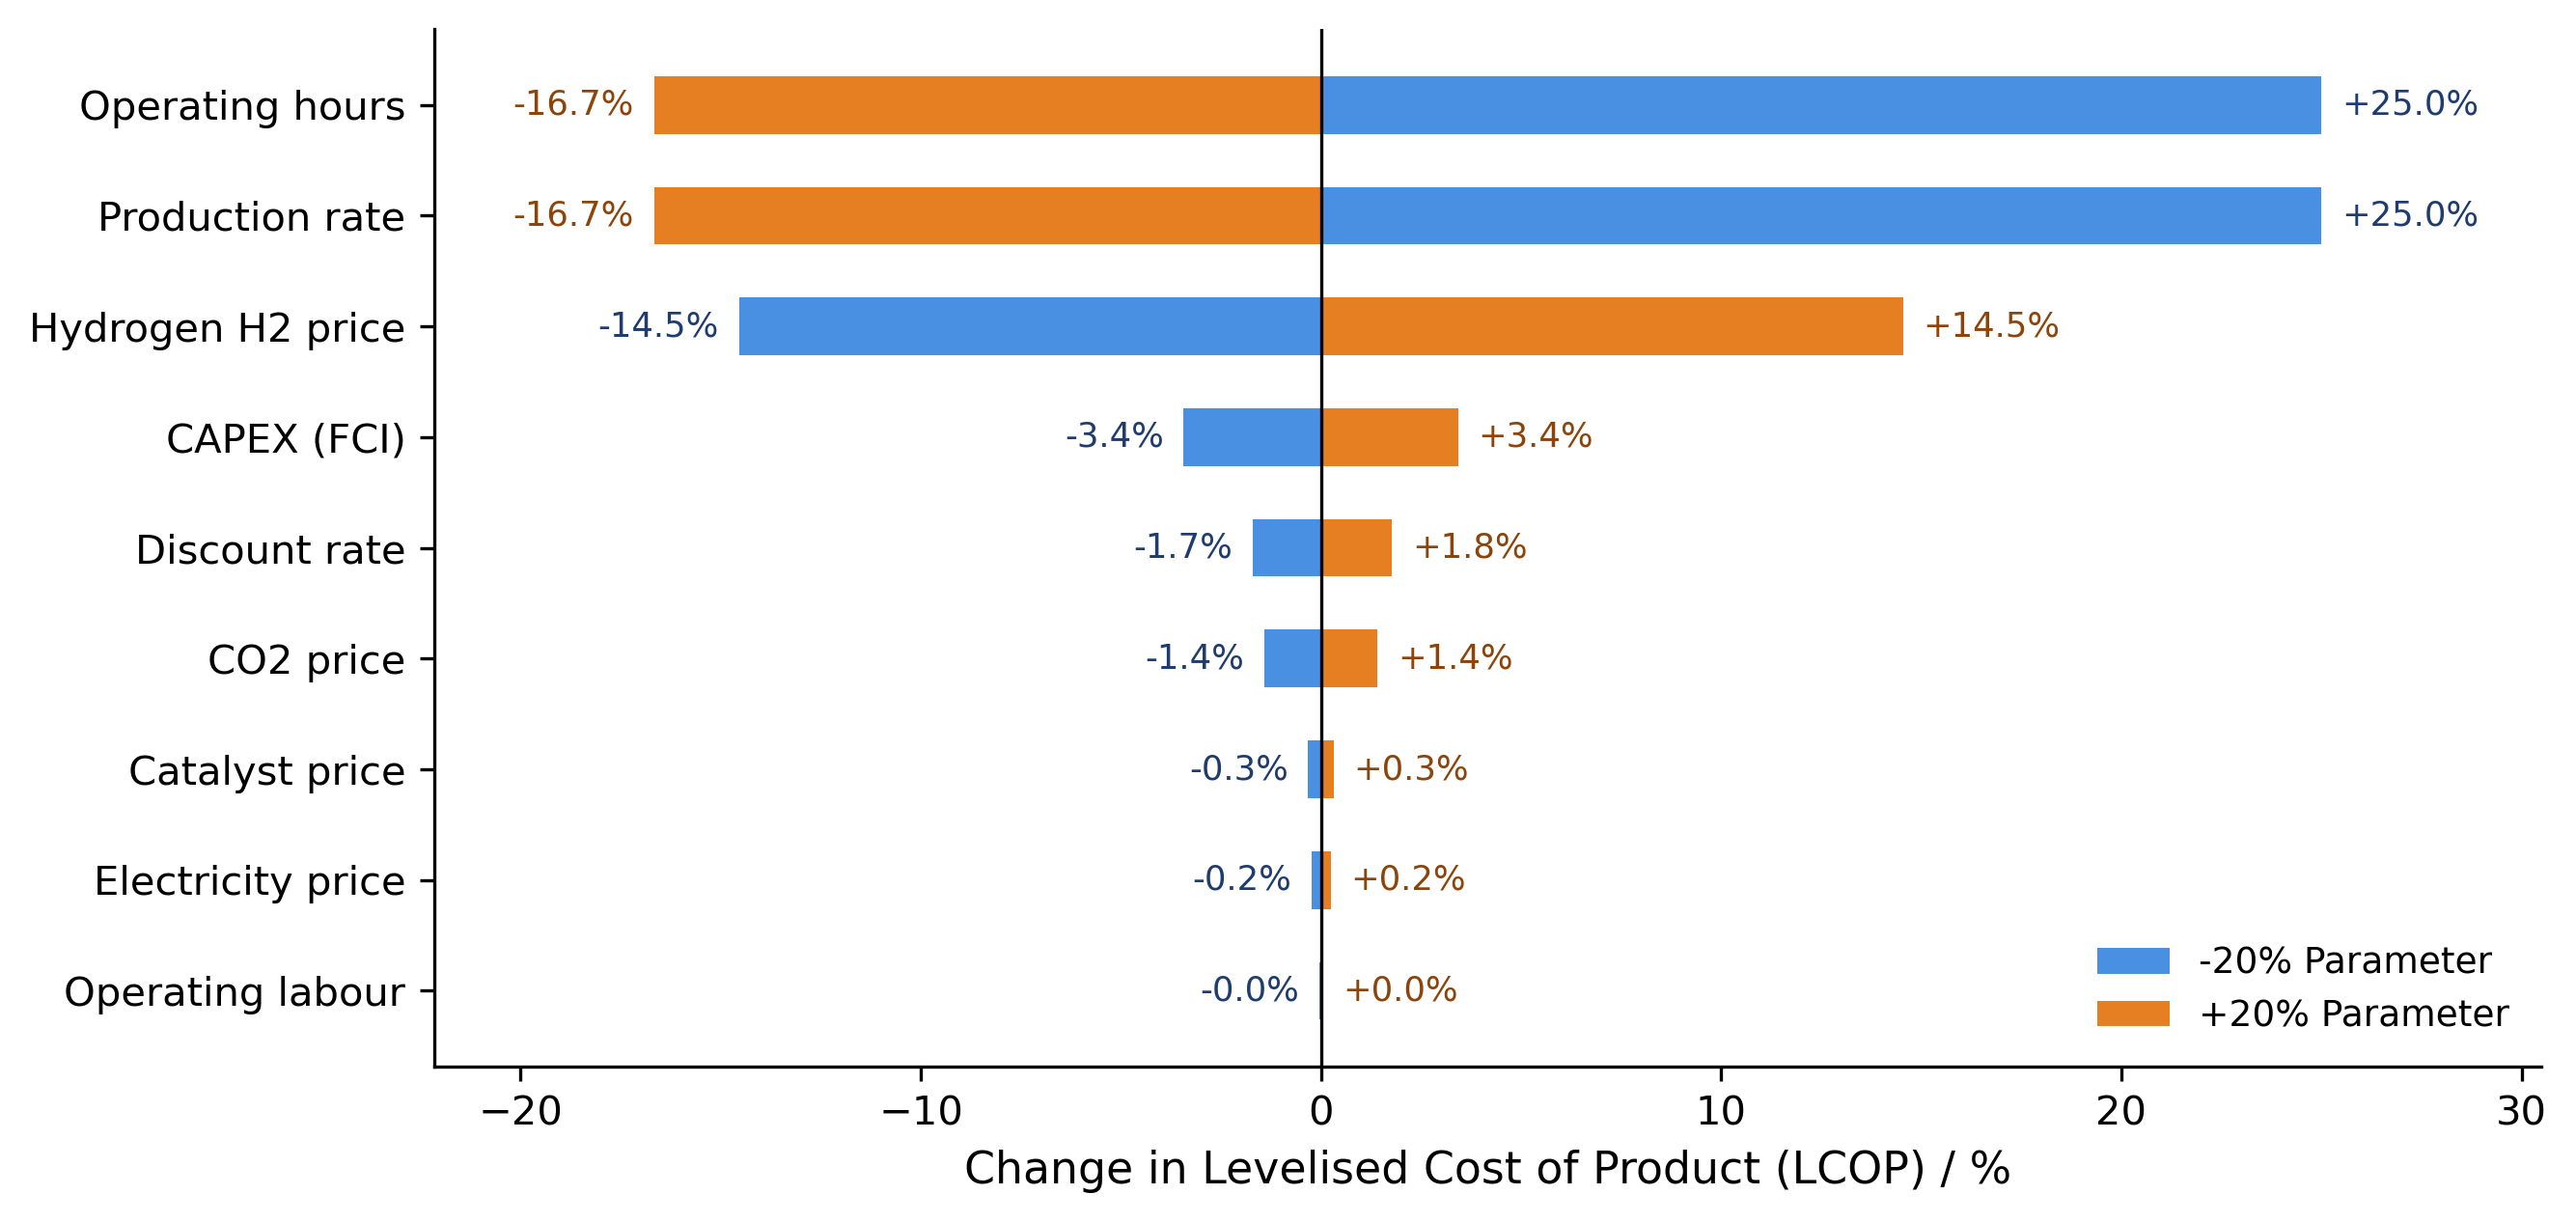

Tornado chart regenerated and saved as 'tornado_plot.png'.


In [ ]:
# ================================================================
# CELL 6 - SENSITIVITY (TORNADO), driven by the same run_case()
# ================================================================
lo_f = 1.0 - sensitivity_range
hi_f = 1.0 + sensitivity_range

cases = []
for _, row in opex_df.iterrows():
    if row['Class'] == 'Labour':
        continue
    cases.append((f"{row['Item']} price",
                  lambda m, it=row['Item']: {'item_price_mult': {it: m}}))
cases += [
    ("CAPEX (FCI)",       lambda m: {'capex_mult': m}),
    ("Product price",     lambda m: {'price_mult': m}),
    ("Operating labour",  lambda m: {'OL_mult': m}),
    ("Production rate",   lambda m: {'prod_mult': m}),
    ("Operating hours",   lambda m: {'hours_mult': m}),
    ("Discount rate",     lambda m: {'r': discount_rate * m}),
]

rows = []
for label, kwargs_fn in cases:
    low = run_case(**kwargs_fn(lo_f))
    high = run_case(**kwargs_fn(hi_f))
    rows.append({
        'Parameter': label,
        f'LCOP -{sensitivity_range:.0%}': round(low['LCOP'], 2),
        'LCOP base': round(BASE['LCOP'], 2),
        f'LCOP +{sensitivity_range:.0%}': round(high['LCOP'], 2),
        'LCOP swing %': round(abs(high['LCOP'] - low['LCOP']) / BASE['LCOP'] * 100, 1)
                        if BASE['LCOP'] else float('nan'),
        f'NPV -{sensitivity_range:.0%} (M)': round(low['NPV'] / 1e6, 2),
        'NPV base (M)': round(BASE['NPV'] / 1e6, 2),
        f'NPV +{sensitivity_range:.0%} (M)': round(high['NPV'] / 1e6, 2),
    })

df_sensitivity = pd.DataFrame(rows).sort_values('LCOP swing %', ascending=False)
print(f"Sensitivity range: +/-{sensitivity_range:.0%}   (base LCOP = {BASE['LCOP']:.2f}, "
      f"base NPV = {BASE['NPV']/1e6:.2f} M)")
print(df_sensitivity.to_string(index=False))
# ================================================================
# AUTOMATED TORNADO PLOT GENERATION (Auto-scaled & Clean Layout)
# ================================================================
import matplotlib.pyplot as plt

# Filter out non-sensitive parameters and sort ascending for display
plot_df = (
    df_sensitivity[df_sensitivity["LCOP swing %"] > 0.01]
    .sort_values("LCOP swing %", ascending=True)
    .copy()
)

if not plot_df.empty:
  col_low = f"LCOP -{sensitivity_range:.0%}"
  col_high = f"LCOP +{sensitivity_range:.0%}"

  # Relative percentage deviations from base LCOP
  low_pct = (plot_df[col_low] - BASE["LCOP"]) / BASE["LCOP"] * 100
  high_pct = (plot_df[col_high] - BASE["LCOP"]) / BASE["LCOP"] * 100

  fig, ax = plt.subplots(
      figsize=(9, max(4.0, len(plot_df) * 0.48)), dpi=300
  )
  y_pos = range(len(plot_df))

  # Horizontal bars: Blue for lower bound, Orange for upper bound
  ax.barh(
      y_pos,
      low_pct,
      color="#4A90E2",
      height=0.52,
      label=f"-{sensitivity_range:.0%} Parameter",
  )
  ax.barh(
      y_pos,
      high_pct,
      color="#E67E22",
      height=0.52,
      label=f"+{sensitivity_range:.0%} Parameter",
  )

  # Baseline reference at 0%
  ax.axvline(0, color="black", linewidth=0.8, linestyle="-")
  ax.set_yticks(y_pos)
  ax.set_yticklabels(plot_df["Parameter"], fontsize=10)
  ax.set_xlabel("Change in Levelised Cost of Product (LCOP) / %", fontsize=11)

  # Dynamic limit expansion with ample margin to prevent text clipping
  min_val = min(low_pct.min(), high_pct.min())
  max_val = max(low_pct.max(), high_pct.max())
  span = max(abs(min_val), abs(max_val))
  ax.set_xlim(min_val - span * 0.22, max_val + span * 0.22)

  # Value labels positioned cleanly at the end of each bar
  for i, (lp, hp) in enumerate(zip(low_pct, high_pct)):
    # Label for low_pct bar
    ha_l = "right" if lp < 0 else "left"
    offset_l = -span * 0.02 if lp < 0 else span * 0.02
    ax.text(
        lp + offset_l,
        i,
        f"{lp:+.1f}%",
        va="center",
        ha=ha_l,
        fontsize=8.5,
        color="#1f3c6e",
    )

    # Label for high_pct bar
    ha_h = "right" if hp < 0 else "left"
    offset_h = -span * 0.02 if hp < 0 else span * 0.02
    ax.text(
        hp + offset_h,
        i,
        f"{hp:+.1f}%",
        va="center",
        ha=ha_h,
        fontsize=8.5,
        color="#8c440a",
    )

  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.legend(frameon=False, loc="lower right", fontsize=9)

  plt.tight_layout()
  plt.savefig("tornado_plot.png", dpi=300, bbox_inches="tight")
  plt.show()
  print("Tornado chart regenerated and saved as 'tornado_plot.png'.")